# Angie Crews -- Part 4 Technical Modification Notebook
# Intro to Web Mining & Applied NLP

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Angie Crews](https://github.com/Angie-Crews/)
- Repository: [nlp-01-getting-started](https://github.com/Angie-Crews/nlp-01-getting-started/)
- Purpose: Demonstrate web mining and applied natural language processing (NLP)
- Date: 2026-03

## Section 0. Intro to Jupyter Notebooks

Tips for Jupyter Notebooks:

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) after editing the cell.
- Change the type of a cell (e.g., to code or markdown) by looking in the lower edge of the cell interface.
- Rearrange cells by dragging and dropping cells.
- Use **File > Save as** to rename and save a notebook. 
- You must select a kernel (Python environment) for your notebook. In VS Code, click **Select Kernel** in the top-right corner of the notebook interface and choose the desired kernel from the dropdown menu. 
- Follow suggestions to install recommended extensions.
- Once installed, click Select Kernel / Python Environments and choose the Recommended `.venv` option created for the project. This creates a new kernel for the notebook to run code using the packages installed in the local `.venv`.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

In [1]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import polars as pl
import requests
from wordcloud import WordCloud

print("Imports complete.")

Imports complete.


## Section 2. Retrieve a Web Page (as HTML text)

In [2]:
# Section 2 Python cell

# Choose a page to analyze.
# The Shakespeare page is simple and stable.
# The Wikipedia page is interesting, but requires a User-Agent header.
# url: str = "https://shakespeare.mit.edu/romeo_juliet/full.html"
url: str = "https://www.gutenberg.org/files/55/55-h/55-h.htm"

# Some sites reject requests that look like anonymous scripts.
# This header helps the request look more like a normal browser visit.
headers: dict[str, str] = {
    "User-Agent": "Mozilla/5.0 (compatible; NLP-Course-Example/1.0)"
}

# Request the page and stop with an error if the request fails.
response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

# Store the raw HTML text.
html: str = response.text

print(f"Downloaded {len(html):,} characters from:")
print(url)

Downloaded 244,507 characters from:
https://www.gutenberg.org/files/55/55-h/55-h.htm


## Section 3. Parse the HTML (into a BeautifulSoup tree)

In [3]:
# Section 3 Python cell

# BeautifulSoup() takes raw HTML text
# and builds a parse tree (a structured representation of the document)
# we assign to a variable named soup (short for "soup of tags").

# Example Input:
# "<html><body><p>Hello</p></body></html>"

# Example BeautifulSoup parse tree:
# html
#  └── body
#       └── p
#            └── "Hello"

# This makes it easier to extract text and inspect page structure.

# Call BeautifulSoup with the raw HTML and a parser (lxml is fast and lenient).
soup: BeautifulSoup = BeautifulSoup(html, "lxml")

print("HTML parsed successfully.")
print(type(soup))

HTML parsed successfully.
<class 'bs4.BeautifulSoup'>


## Section 4. Extract Visible Text from the HTML

In [4]:
# Section 4 Python cell

# Extract visible text from the page with get_text() method.
# separator=" " inserts spaces between chunks of text.
# strip=True removes leading and trailing whitespace.
text: str = soup.get_text(separator=" ", strip=True)

# Use [0:1000] to show only the first 1000 characters of the text.
# Or [:1000] gives the same result, since the start index defaults to 0.
print("First 1000 characters of extracted text:")
print(text[:1000])

First 1000 characters of extracted text:
The Wonderful Wizard of Oz | Project Gutenberg *** START OF THE PROJECT GUTENBERG EBOOK 55 *** The Wonderful Wizard of Oz by L. Frank Baum This book is dedicated to my good friend & comrade My Wife L.F.B. Contents Introduction Chapter I. The Cyclone Chapter II. The Council with the Munchkins Chapter III. How Dorothy Saved the Scarecrow Chapter IV. The Road Through the Forest Chapter V. The Rescue of the Tin Woodman Chapter VI.  The Cowardly Lion Chapter VII. The Journey to the Great Oz Chapter VIII. The Deadly Poppy Field Chapter IX. The Queen of the Field Mice Chapter X. The Guardian of the Gates Chapter XI. The Emerald City of Oz Chapter XII. The Search for the Wicked Witch Chapter XIII. The Rescue Chapter XIV. The Winged Monkeys Chapter XV. The Discovery of Oz, the Terrible Chapter XVI. The Magic Art of the Great Humbug Chapter XVII. How the Balloon Was Launched Chapter XVIII. Away to the South Chapter XIX. Attacked by the Fighting Trees Chap

## Section 5. Clean the Text (split, lowercase, remove punctuation)

In [5]:
# Section 5 Python cell

# Split the text into words
words = text.split()
print("Raw word count:", len(words))

# Convert to lowercase
words = [w.lower() for w in words]

# Remove punctuation first
tokens = [w.strip(".,:;!?()[]\"'") for w in words]

# New logic: remove short tokens + common stopwords
stopwords = {
    "the",
    "and",
    "for",
    "with",
    "that",
    "this",
    "from",
    "are",
    "was",
    "were",
    "have",
    "has",
    "had",
    "not",
    "you",
    "your",
    "they",
    "their",
    "them",
    "into",
    "about",
    "which",
    "what",
    "when",
    "where",
}
clean_words = [w for w in tokens if len(w) > 3 and w not in stopwords]

print("Clean word count:", len(clean_words))
print("First 20 cleaned words:", clean_words[:20])

Raw word count: 39689
Clean word count: 19056
First 20 cleaned words: ['wonderful', 'wizard', 'project', 'gutenberg', 'start', 'project', 'gutenberg', 'ebook', 'wonderful', 'wizard', 'frank', 'baum', 'book', 'dedicated', 'good', 'friend', 'comrade', 'wife', 'l.f.b', 'contents']


## Section 6. Build a Frequency Table (Polars)

In [6]:
# Section 6 Python cell

# For working with tabular data,
# Polars is faster and smaller than pandas,
# has a more modern API, and the concepts are similar.

# Create a Polars DataFrame (df) with one row per word with a column named "word".
df: pl.DataFrame = pl.DataFrame({"word": clean_words})

# Group by word, count occurrences, and sort from most common to least common.
# This is a powerful pattern for counting and summarizing data in Polars.
# Function chain: group_by() -> len() -> sort()
freq_df: pl.DataFrame = df.group_by("word").len().sort("len", descending=True)

print("Top 20 most frequent words:")
print(freq_df.head(20))

Top 20 most frequent words:
shape: (20, 2)
┌───────────┬─────┐
│ word      ┆ len │
│ ---       ┆ --- │
│ str       ┆ u32 │
╞═══════════╪═════╡
│ dorothy   ┆ 340 │
│ said      ┆ 331 │
│ scarecrow ┆ 215 │
│ woodman   ┆ 175 │
│ lion      ┆ 169 │
│ …         ┆ …   │
│ green     ┆ 99  │
│ back      ┆ 96  │
│ down      ┆ 91  │
│ girl      ┆ 90  │
│ made      ┆ 88  │
└───────────┴─────┘


## Section 7. Build "Most Frequent Words" Bar Chart

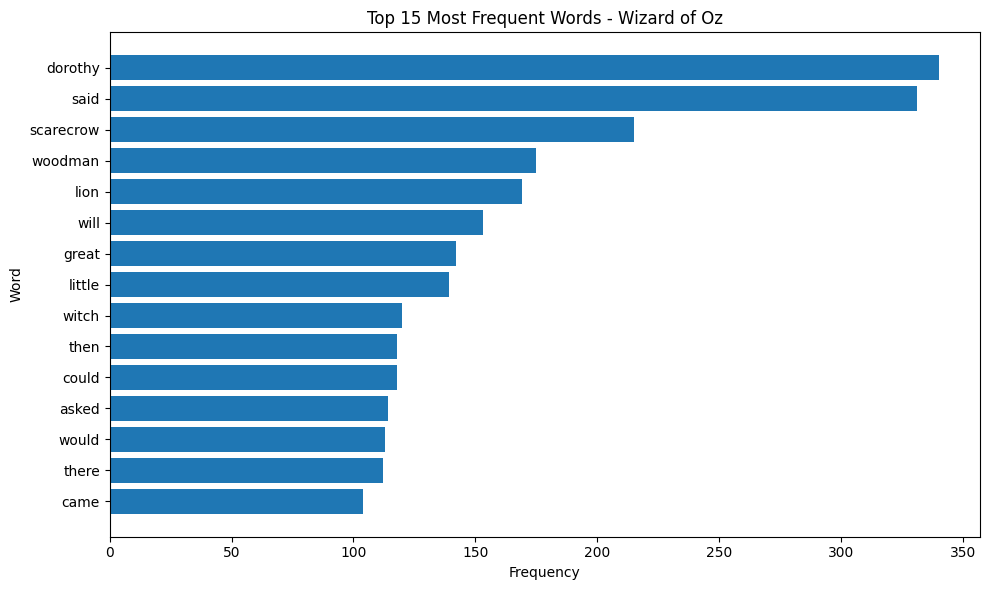

In [7]:
# Section 7 Python cell (updated output only)

top_n = 15
top_df = freq_df.head(top_n).sort("len")  # sort for horizontal bar readability

plt.figure(figsize=(10, 6))
plt.barh(top_df["word"], top_df["len"])
plt.title(f"Top {top_n} Most Frequent Words - Wizard of Oz")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## Section 8. Build a Word Cloud

Sample of word frequencies:
dorothy: 340
said: 331
scarecrow: 215
woodman: 175
lion: 169
will: 153
great: 142
little: 139
witch: 120
then: 118


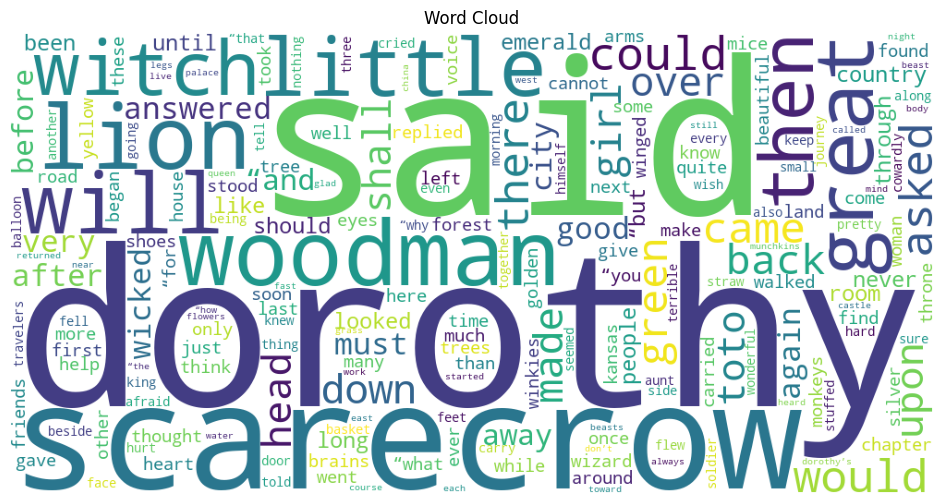

In [8]:
# Section 8 Python cell

# For this, we want a Python dictionary
# mapping words to their frequencies.
# We can use the zip() function to combine the "word" and "len" columns into a dictionary.
# First, convert the frequency dfs to lists with to_list(),
# then zip() them together into a dictionary.
# strict=True ensures both lists are the same length.
freq_dict: dict[str, int] = dict(
    zip(freq_df["word"].to_list(), freq_df["len"].to_list(), strict=True)
)
print("Sample of word frequencies:")
for word, freq in list(freq_dict.items())[:10]:
    print(f"{word}: {freq}")

# Build a word cloud where larger words occur more frequently in the text.
# Set width and height in pixels and set the background color.
wc: WordCloud = WordCloud(
    width=1000, height=500, background_color="white", colormap="viridis"
)

# Generate the word cloud from the frequency dictionary.
wc.generate_from_frequencies(freq_dict)

# Set the figure size in inches
plt.figure(figsize=(12, 6))

# Display the word cloud image with imshow() and turn off axes for a cleaner look.
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 